# Projet 9 — Analysez les ventes d'une librairie avec Python

In [ ]:
#Import des bibliothèque NumPy, Pandas et Matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) Import drive from google.colab
from google.colab import drive
drive.mount('/content/drive')

# 2) Charger les CSV BRUTS
df_products = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/products.csv", sep=";")
df_customers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/customers.csv", sep=";")
df_transactions = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/Transactions.csv", sep=";")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_15901/1197497098.py:8: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P9/data/Transactions.csv", sep=";")


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [ ]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [ ]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [ ]:
#Vérication des noms de colonnes
print("Transactions :", df_transactions.columns.tolist())
print("Products :", df_products.columns.tolist())
print("Customers :", df_customers.columns.tolist())

Transactions : ['id_prod', 'date', 'session_id', 'client_id']
Products : ['id_prod', 'price', 'categ']
Customers : ['client_id', 'sex', 'birth']


In [ ]:
# Vérification des valeurs manquantes avant nettoyage
print("Valeurs manquantes - transactions")
print(df_transactions.isna().sum())

print("\nValeurs manquantes - customers")
print(df_customers.isna().sum())

print("\nValeurs manquantes - products")
print(df_products.isna().sum())

Valeurs manquantes - transactions
id_prod       361041
date          361041
session_id    361041
client_id     361041
dtype: int64

Valeurs manquantes - customers
client_id    0
sex          0
birth        0
dtype: int64

Valeurs manquantes - products
id_prod    0
price      0
categ      0
dtype: int64


##Nettoyage de base des tables

In [ ]:
# Supprimer les espaces inutiles dans les noms de colonnes
df_transactions.columns = df_transactions.columns.str.strip()
df_products.columns = df_products.columns.str.strip()
df_customers.columns = df_customers.columns.str.strip()

In [ ]:
# Supprimer les espaces inutiles dans les colonnes texte -  Nettoyage des clés de jointure
df_transactions["client_id"] = df_transactions["client_id"].astype(str).str.strip()
df_transactions["id_prod"] = df_transactions["id_prod"].astype(str).str.strip()

df_products["id_prod"] = df_products["id_prod"].astype(str).str.strip()
df_customers["client_id"] = df_customers["client_id"].astype(str).str.strip()

In [ ]:
# Suppression des lignes sans date dans la table des transactions
df_transactions = df_transactions[df_transactions["date"].notna()]

##Vérification des doublons sur les clés

In [ ]:
print("Doublons client_id dans customers :", df_customers["client_id"].duplicated().sum())
print("Doublons id_prod dans products :", df_products["id_prod"].duplicated().sum())

Doublons client_id dans customers : 0
Doublons id_prod dans products : 0


## Définition des liaisons entre les tables

In [ ]:
# Jointure transactions + clients
df_trans_cust = pd.merge(
    df_transactions,
    df_customers,
    on="client_id",
    how="left")

In [ ]:
# Jointure avec les produits
df_final = pd.merge(
    df_trans_cust,
    df_products,
    on="id_prod",
    how="left")

In [ ]:
# Vérification
print("Shape transactions :", df_transactions.shape)
print("Shape final :", df_final.shape)

display(df_final.head())

Shape transactions : (687534, 4)
Shape final : (687534, 8)


,id_prod,date,session_id,client_id,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0


La table transactions constitue la table centrale de l’analyse.
Elle contient les identifiants client_id et id_prod, permettant de la relier respectivement à la table customers et à la table products.
Nous effectuons donc des jointures à gauche (left join) afin de conserver l’ensemble des transactions, même en cas d’absence de correspondance dans les tables annexes.

##1. Vérification des types de données


In [ ]:
# Conversion des types
df_final["date"] = pd.to_datetime(df_final["date"])

df_final["price"] = pd.to_numeric(df_final["price"], errors="coerce")

df_final["birth"] = pd.to_numeric(df_final["birth"], errors="coerce")

df_final["categ"] = df_final["categ"].astype("category")

In [ ]:
#Création de la variable "âge"
df_final["age"] = df_final["date"].dt.year - df_final["birth"]

In [ ]:
df_final["age"].head()

,age
0,54
1,61
2,33
3,32
4,65


## 2. Vérification des valeurs manquantes

In [ ]:
df_final[df_final["price"].isna()].head()

,id_prod,date,session_id,client_id,sex,birth,price,categ,age


In [ ]:
df_final[df_final["sex"].isna()].head()

,id_prod,date,session_id,client_id,sex,birth,price,categ,age


In [ ]:
df_final.duplicated().sum()

np.int64(0)

## 3. Inspection des donnes

In [ ]:
df_final.columns.tolist()

['id_prod',
 'date',
 'session_id',
 'client_id',
 'sex',
 'birth',
 'price',
 'categ',
 'age']

In [ ]:
#Est-ce qu’il y a des caractères autres que des lettres
df_final["client_id"].str.contains(r"[^a-zA-Z0-9_]", regex=True).sum()

np.int64(0)

In [ ]:
df_final["id_prod"].str.contains(r"[^a-zA-Z0-9_]", regex=True).sum()

np.int64(0)

In [ ]:
df_final["sex"].str.contains(r"[^a-zA-Z]", regex=True).sum()

np.int64(0)

In [ ]:
#Vérification des prix anormaux
df_final[df_final["price"] <= 0]

,id_prod,date,session_id,client_id,sex,birth,price,categ,age


In [ ]:
#Âge incohérent +100ans
df_final[(df_final["age"] < 0) | (df_final["age"] > 100)]

,id_prod,date,session_id,client_id,sex,birth,price,categ,age


In [ ]:
#+80?
df_final[(df_final["age"] < 0) | (df_final["age"] > 80)]

,id_prod,date,session_id,client_id,sex,birth,price,categ,age
197,0_1467,2021-03-01 04:31:02.343724,s_107,c_5558,f,1937,4.99,0,84
203,1_606,2021-03-01 04:38:25.870290,s_107,c_5558,f,1937,28.00,1,84
256,1_431,2021-03-01 06:20:28.254488,s_140,c_5626,m,1939,27.99,1,82
295,1_483,2021-03-01 07:17:18.264876,s_154,c_5089,f,1940,15.99,1,81
300,1_425,2021-03-01 07:25:07.336024,s_154,c_5089,f,1940,16.99,1,81
...,...,...,...,...,...,...,...,...,...
687297,0_1382,2023-02-28 18:06:02.695703,s_348328,c_3366,f,1938,15.62,0,85
687385,1_534,2023-02-28 20:28:06.428195,s_348374,c_5041,f,1942,13.43,1,81
687433,1_468,2023-02-28 21:31:44.187207,s_348398,c_2377,f,1937,17.75,1,86
687458,1_397,2023-02-28 22:18:04.263164,s_348414,c_1208,m,1934,18.99,1,89


<Axes: >

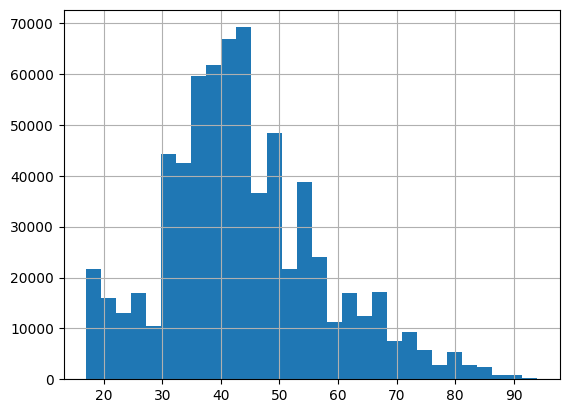

In [ ]:
#Vérifier la distribution
df_final["age"].hist(bins=30)

La distribution des âges montre une concentration des clients entre 30 et 50 ans.


In [ ]:
#Sexe incohérent
df_final["sex"].value_counts()

,count
sex,
m,344841
f,342693


In [ ]:
# Vérification de la cohérence des dates
df_final["date"].min(), df_final["date"].max()

(Timestamp('2021-03-01 00:01:07.843138'),
 Timestamp('2023-02-28 23:58:30.792755'))

Les dates s'étendent de 2021 à 2023, ce qui est cohérent avec la période d'analyse

# KPI principaux
---
1. Chiffre d’affaires total
2. Nombre de transactions
3. Nombre de clients uniques
4. Chiffre d’affaires par mois + moyenne mobile
5. CA par catégorie
6. Top produits
7. Flop produits
8. Nombre de clients par mois
9. Courbe de lorenz

## 1. Indicateurs globaux

### Chiffre d’affaires total



In [ ]:

ca_total = df_final["price"].sum()
print(f"Chiffre d'affaires total : {ca_total:,.0f} €")

Chiffre d'affaires total : 12,027,663 €


### Analyse commande



In [ ]:
#Nombre de transactions (lignes)
nb_transactions = df_final.shape[0]
print("Nombre de lignes (produits vendus) :", nb_transactions)

Nombre de lignes (produits vendus) : 687534


In [ ]:
#Nombre de commandes réelles
nb_commandes = df_final["session_id"].nunique()
print("Nombre de commandes :", nb_commandes)

Nombre de commandes : 345505


Chaque ligne correspond à un produit acheté.
Une commande peut contenir plusieurs produits (identifiés par session_id).

In [ ]:
nb_moyen_panier = df_final.groupby("session_id")["id_prod"].count().mean()
print(f"Nombre moyen de produits par commande : {nb_moyen_panier:.1f}")

Nombre moyen de produits par commande : 2.0


Le nombre de produits par commande est en moyenne d’environ,
ce qui est cohérent avec un comportement d’achat classique.

### Nombre d’achats par client

In [ ]:
freq_client = df_final.groupby("client_id")["id_prod"].count()
freq_client

,id_prod
client_id,
c_1,43
c_10,58
c_100,8
c_1000,126
c_1001,103
...,...
c_995,14
c_996,96
c_997,59


### Nombre de clients uniques

In [ ]:
nb_clients = df_final["client_id"].nunique()
print("Nombre de clients uniques :", nb_clients)

Nombre de clients uniques : 8600


### Panier moyen en € par client

In [ ]:
df_final.columns.tolist()

['id_prod',
 'date',
 'session_id',
 'client_id',
 'sex',
 'birth',
 'price',
 'categ',
 'age']

In [ ]:
df_final

,id_prod,date,session_id,client_id,sex,birth,price,categ,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0,54
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0,61
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0,33
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0,32
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0,65
...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,f,1996,21.92,1,27
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,f,1994,48.99,2,29
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,f,1985,26.99,1,38
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,m,1953,8.99,0,70


In [ ]:
panier_moyen = df_final.groupby("client_id")["price"].mean()
panier_moyen.head()

,price
client_id,
c_1,14.628372
c_10,23.337931
c_100,31.856250
c_1000,18.189524
c_1001,17.707282


### Calcul de la fréquence d'achat par client

In [ ]:
# La fréquence correspond au nombre de commandes réalisées par chaque client
freq_client = df_final.groupby("client_id")["session_id"].nunique()

## 2. Analyse temporelle

### Chiffre d’affaires par mois

In [ ]:
df_final.columns.tolist()

['id_prod',
 'date',
 'session_id',
 'client_id',
 'sex',
 'birth',
 'price',
 'categ',
 'age']

In [ ]:
df_final['date'] = pd.to_datetime(df_final['date'])


In [ ]:
ca_mensuel = df_final.groupby(
    df_final['date'].dt.to_period('M'))['price'].sum()
print("Chiffre d'affaires mensuel :")
print(ca_mensuel)

Chiffre d'affaires mensuel :
date
2021-03    482440.61
2021-04    476109.30
2021-05    492943.47
2021-06    484088.56
2021-07    482835.40
2021-08    482284.79
2021-09    507240.68
2021-10    494733.16
2021-11    516167.73
2021-12    525917.28
2022-01    525338.99
2022-02    535571.50
2022-03    515456.53
2022-04    492998.94
2022-05    517132.60
2022-06    496016.12
2022-07    510783.12
2022-08    506467.27
2022-09    494114.53
2022-10    507917.77
2022-11    496664.94
2022-12    510219.50
2023-01    517540.55
2023-02    456679.76
Freq: M, Name: price, dtype: float64


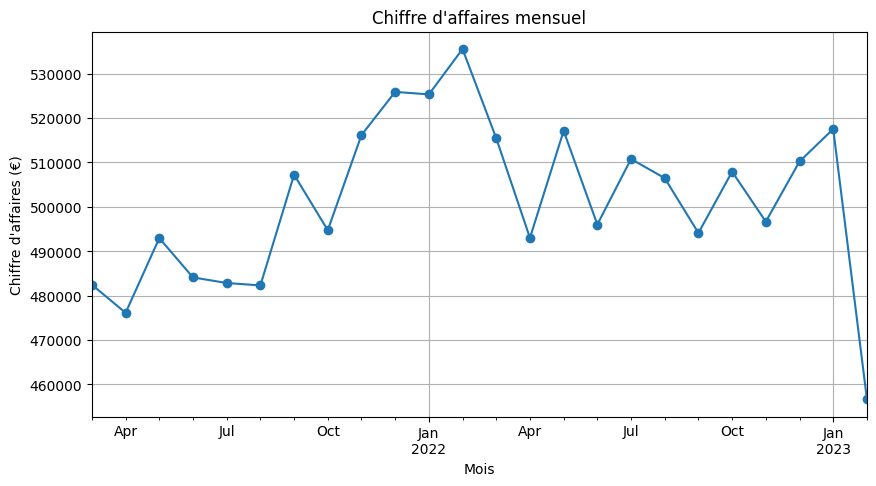

In [ ]:
#Visual plotlib
ca_mensuel.plot(figsize=(10,5), marker='o')
plt.title("Chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.grid(True)
plt.show()

### Moyenne mobile

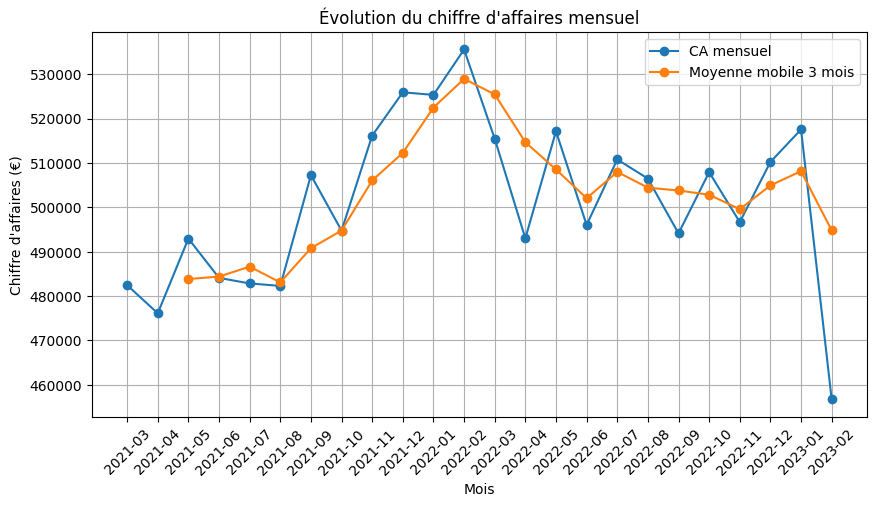

In [ ]:
moyenne_mobile = ca_mensuel.rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(ca_mensuel.index.astype(str), ca_mensuel.values, marker='o', label="CA mensuel")
plt.plot(moyenne_mobile.index.astype(str), moyenne_mobile.values, marker='o', label="Moyenne mobile 3 mois")
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

###Nombre de clients par mois

In [ ]:
#creation d'une variable mois
df_final["year_month"] = df_final["date"].dt.to_period("M")

In [ ]:
clients_par_mois = df_final.groupby("year_month")["client_id"].nunique()

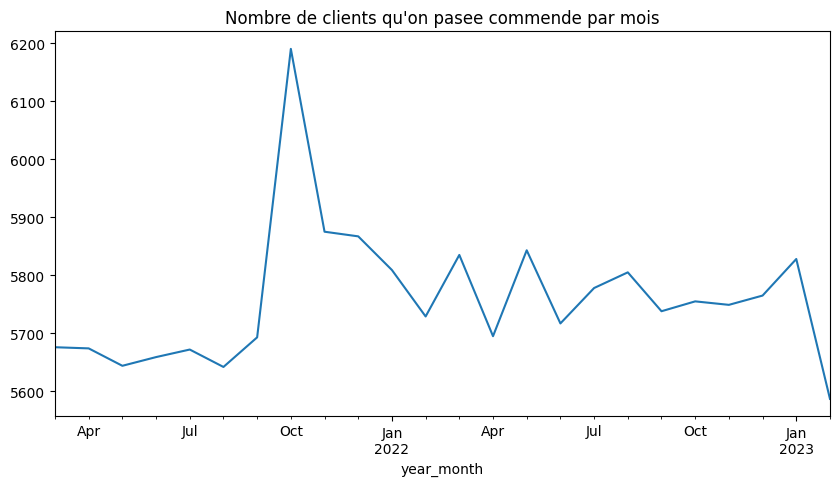

In [ ]:

clients_par_mois.plot(figsize=(10,5), title="Nombre de clients qu'on pasee commende par mois")
plt.show()

évolution globalement stable entre 5600 et 5900.
pic marqué vers octobre (~6200)

## 3. Analyse produits

### CA par catégorie

In [ ]:
# Chiffre d'affaires par catégorie
ca_par_categ = df_final.groupby("categ")["price"].sum()
ca_par_categ

/tmp/ipykernel_15901/1740857551.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ca_par_categ = df_final.groupby("categ")["price"].sum()


,price
categ,
0,4419730.97
1,4827657.11
2,2780275.02


In [ ]:
df_final["categ"].value_counts()

,count
categ,
0,415459
1,235592
2,36483


In [ ]:
# Les catégories étant codées sous forme numérique (0, 1, 2),
# nous créons des libellés pour améliorer la lisibilité des graphiques.
# Faute d’information métier, les catégories sont conservées sous forme générique.
df_final["categ_label"] = df_final["categ"].map({
    0: "Catégorie 0",
    1: "Catégorie 1",
    2: "Catégorie 2"})

/tmp/ipykernel_15901/3316126947.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ca_par_categ = df_final.groupby("categ_label")["price"].sum()


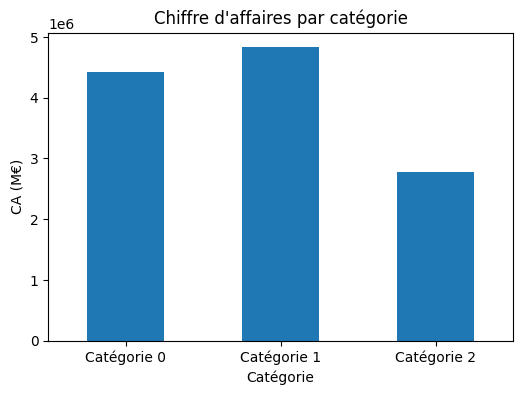

In [ ]:
#graphique

ca_par_categ = df_final.groupby("categ_label")["price"].sum()

plt.figure(figsize=(6,4))
ca_par_categ.plot(kind="bar")

plt.title("Chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("CA (M€)")
plt.xticks(rotation=0)

plt.show()


La catégorie 1 génère le chiffre d’affaires le plus élevé, suivie de la catégorie 0.
La catégorie 2 est en retrait, ce qui peut indiquer une moindre attractivité ou un volume de ventes plus faible sur cette catégorie.

### Top produits

In [ ]:
top_products= (
    df_final.groupby("id_prod")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10))

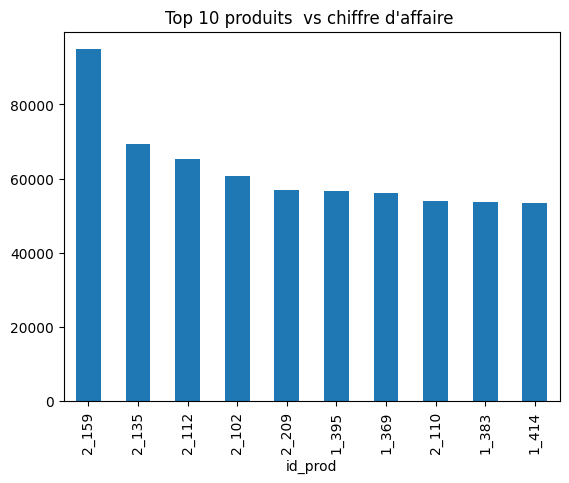

In [ ]:
top_products.plot(kind="bar", title="Top 10 produits  vs chiffre d'affaire ")
plt.show()

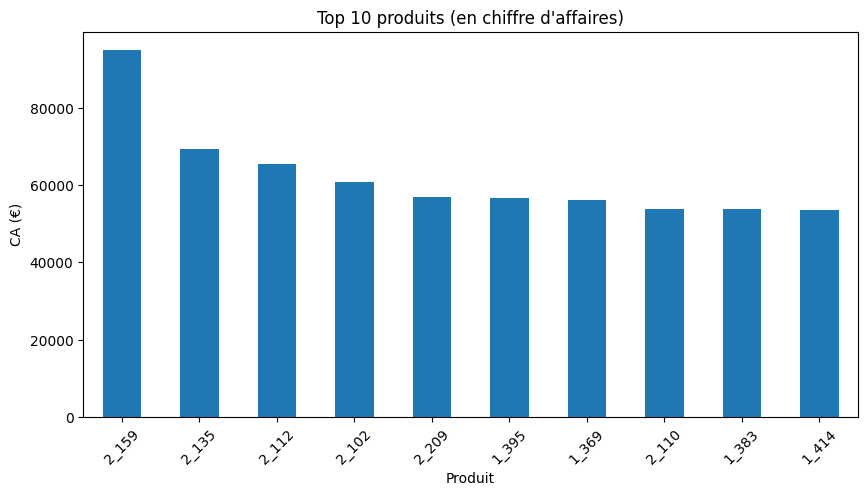

In [ ]:
#graphique
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top 10 produits (en chiffre d'affaires)")
plt.xlabel("Produit")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)

plt.show()

### Flop produits

In [ ]:
flop_products = (
    df_final.groupby("id_prod")["price"] .sum() .sort_values().head(10))

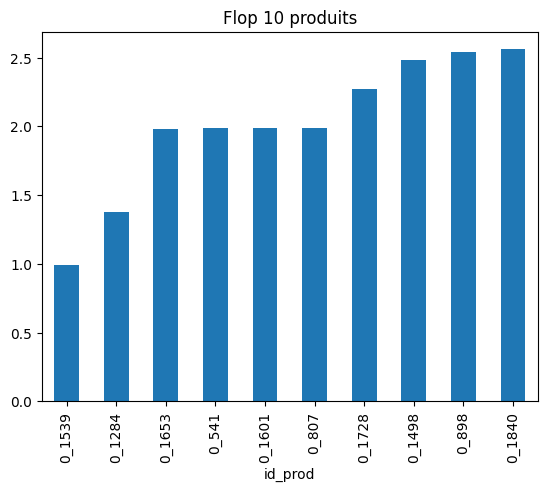

In [ ]:
flop_products.plot(kind="bar", title="Flop 10 produits")
plt.show()

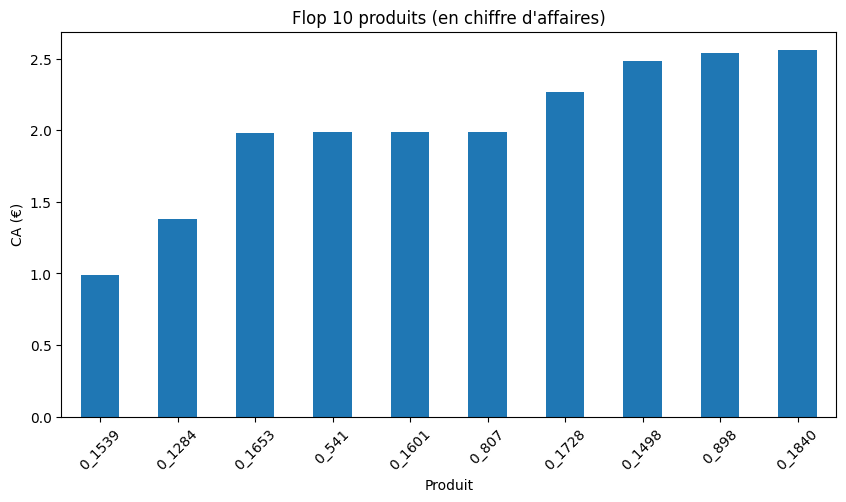

In [ ]:
#graphique
plt.figure(figsize=(10,5))
flop_products.plot(kind="bar")
plt.title("Flop 10 produits (en chiffre d'affaires)")
plt.xlabel("Produit")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)

plt.show()

## 4. Analyse clients

### Age moyen par client

In [ ]:
# âge moyen par client
age_client = df_final.groupby("client_id")["age"].mean()

### Courbe de lorenz

In [ ]:
ca_client = df_final.groupby('client_id')['price'].sum()
ca_client_sorted = np.sort(ca_client)

In [ ]:
# Cumul
cum_ca = np.cumsum(ca_client_sorted)
cum_ca = cum_ca / cum_ca[-1]

In [ ]:
# Population
n = len(ca_client_sorted)
cum_pop = np.arange(1, n+1) / n


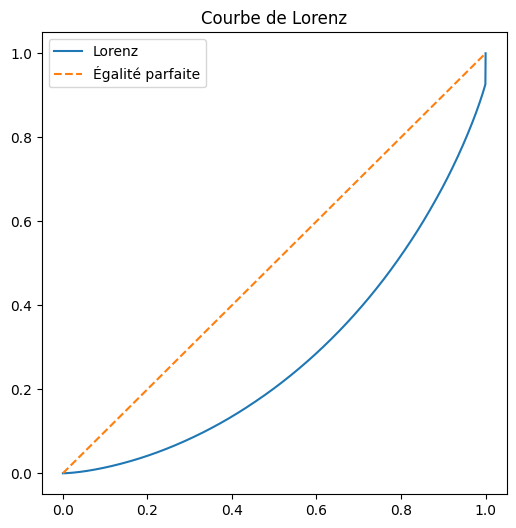

In [ ]:
# Graphique
plt.figure(figsize=(6,6))
plt.plot(cum_pop, cum_ca, label="Lorenz")
plt.plot([0,1], [0,1], linestyle="--", label="Égalité parfaite")
plt.title("Courbe de Lorenz")
plt.legend()
plt.show()

In [ ]:
#la courbe est loin de la diagonale et elle est très courbée vers le bas


La courbe de Lorenz permet d’analyser la répartition du chiffre d’affaires entre les clients.

La ligne orange représente une égalité parfaite : chaque client générerait la même part du chiffre d’affaires.

La courbe bleue s’éloigne de cette diagonale, ce qui montre que la répartition des ventes est inégale.

On observe qu’une partie des clients génère une grande part du chiffre d’affaires, tandis qu’une majorité de clients contribue moins aux ventes.

Cependant, l’écart avec la ligne d’égalité reste modéré : les ventes ne sont donc pas totalement concentrées sur quelques clients uniquement.

In [ ]:
df_final.to_csv("/content/drive/MyDrive/df_final_clean.csv", index=False)